# PROBLEM **STATEMENT**


These crimes encompass a wide range of offenses, including domestic violence, sexual assault, dowry-related harassment, human trafficking, and more. We have to analyze by state wise , dowry cases , crime rates etc.


---



Importing Libraries

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px



from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from joblib import Parallel, delayed
import gc


import warnings
warnings.filterwarnings("ignore")


Data Loading

In [39]:
df = pd.read_csv("/content/CrimesOnWomenData.csv")

In [40]:
df.head(4)

,Unnamed: 0,State,Year,Rape,K&A,DD,AoW,AoM,DV,WT
0,0,ANDHRA PRADESH,2001,871,765,420,3544,2271,5791,7
1,1,ARUNACHAL PRADESH,2001,33,55,0,78,3,11,0
2,2,ASSAM,2001,817,1070,59,850,4,1248,0
3,3,BIHAR,2001,888,518,859,562,21,1558,83


In [41]:
df.tail(4)

,Unnamed: 0,State,Year,Rape,K&A,DD,AoW,AoM,DV,WT
732,732,Daman & Diu,2021,315,904,16,1851,10,501,1
733,733,Delhi UT,2021,2,1,0,5,1,9,0
734,734,Lakshadweep,2021,0,0,0,1,1,3,0
735,735,Puducherry,2021,2,0,2,31,3,12,0


In [42]:
pd.options.display.max_columns = None



Data Cleaning

In [43]:
df.shape

(736, 10)

In [44]:
df.columns

Index(['Unnamed: 0', 'State', 'Year', 'Rape', 'K&A', 'DD', 'AoW', 'AoM', 'DV',
       'WT'],
      dtype='object')

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 736 entries, 0 to 735
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  736 non-null    int64 
 1   State       736 non-null    object
 2   Year        736 non-null    int64 
 3   Rape        736 non-null    int64 
 4   K&A         736 non-null    int64 
 5   DD          736 non-null    int64 
 6   AoW         736 non-null    int64 
 7   AoM         736 non-null    int64 
 8   DV          736 non-null    int64 
 9   WT          736 non-null    int64 
dtypes: int64(9), object(1)
memory usage: 57.6+ KB


In [46]:
df.describe()

,Unnamed: 0,Year,Rape,K&A,DD,AoW,AoM,DV,WT
count,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000
mean,367.500000,2011.149457,727.855978,1134.542120,215.692935,1579.115489,332.722826,2595.078804,28.744565
std,212.609188,6.053453,977.024945,1993.536828,424.927334,2463.962518,806.024551,4042.004953,79.999660
min,0.000000,2001.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,183.750000,2006.000000,35.000000,24.750000,1.000000,34.000000,3.000000,13.000000,0.000000
50%,367.500000,2011.000000,348.500000,290.000000,29.000000,387.500000,31.000000,678.500000,0.000000
75%,551.250000,2016.000000,1069.000000,1216.000000,259.000000,2122.250000,277.500000,3545.000000,15.000000
max,735.000000,2021.000000,6337.000000,15381.000000,2524.000000,14853.000000,9422.000000,23278.000000,549.000000


In [47]:
df.isnull().sum()

,0
Unnamed: 0,0
State,0
Year,0
Rape,0
K&A,0
DD,0
AoW,0
AoM,0
DV,0
WT,0


In [48]:
(df.isnull().sum()/len(df))*100

,0
Unnamed: 0,0.0
State,0.0
Year,0.0
Rape,0.0
K&A,0.0
DD,0.0
AoW,0.0
AoM,0.0
DV,0.0
WT,0.0


In [49]:
df.fillna(df.median(numeric_only=True), inplace=True)

In [50]:
df.fillna(df.mode().iloc[0], inplace = True)

In [51]:
df.duplicated().sum()

np.int64(0)

In [52]:
df.drop_duplicates(inplace = True)

In [53]:
df["State"].unique()

array(['ANDHRA PRADESH', 'ARUNACHAL PRADESH', 'ASSAM', 'BIHAR',
       'CHHATTISGARH', 'GOA', 'GUJARAT', 'HARYANA', 'HIMACHAL PRADESH',
       'JAMMU & KASHMIR', 'JHARKHAND', 'KARNATAKA', 'KERALA',
       'MADHYA PRADESH', 'MAHARASHTRA', 'MANIPUR', 'MEGHALAYA', 'MIZORAM',
       'NAGALAND', 'ODISHA', 'PUNJAB', 'RAJASTHAN', 'SIKKIM',
       'TAMIL NADU', 'TRIPURA', 'UTTAR PRADESH', 'UTTARAKHAND',
       'WEST BENGAL', 'A & N ISLANDS', 'CHANDIGARH', 'D & N HAVELI',
       'DAMAN & DIU', 'LAKSHADWEEP', 'PUDUCHERRY', 'Andhra Pradesh',
       'Arunachal Pradesh', 'Assam', 'Bihar', 'Chhattisgarh', 'Goa',
       'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu & Kashmir',
       'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh',
       'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland',
       'Odisha', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu',
       'Telangana', 'Tripura', 'Uttar Pradesh', 'Uttarakhand',
       'West Bengal', 'A & N Islands', 'Chandigarh', 'D&N Haveli',
  

In [54]:
df["State"].nunique()

70

Feature Engineering

In [55]:
# i will create a now coulumn for total crime

In [56]:
crime_cols = [
    'Rape',
    'K&A',
    'DD',
    'AoW',
    'AoM',
    'DV',
    'WT'
]

df['Total_Crimes'] = df[crime_cols].sum(axis=1)

In [57]:
df.head(3)

,Unnamed: 0,State,Year,Rape,K&A,DD,AoW,AoM,DV,WT,Total_Crimes
0,0,ANDHRA PRADESH,2001,871,765,420,3544,2271,5791,7,13669
1,1,ARUNACHAL PRADESH,2001,33,55,0,78,3,11,0,180
2,2,ASSAM,2001,817,1070,59,850,4,1248,0,4048


Q1 Top States with Highest Crimes

In [58]:
state_crime = df.groupby('State')['Total_Crimes'].sum().sort_values(ascending = False)
state_crime.head(10)

,Total_Crimes
State,
Uttar Pradesh,350934
West Bengal,265807
Madhya Pradesh,262794
Rajasthan,243022
Maharashtra,232095
Assam,223410
Andhra Pradesh,200042
ANDHRA PRADESH,191081
UTTAR PRADESH,178800


Exploratory Data Analysis

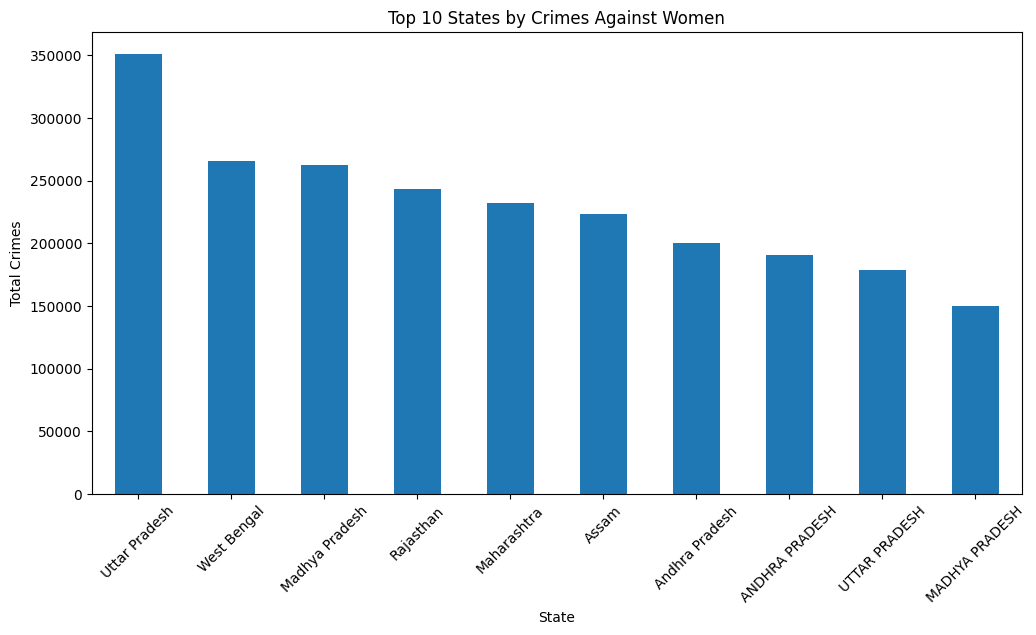

In [92]:
plt.figure(figsize=(12,6))

state_crime.head(10).plot(kind='bar')


plt.title('Top 10 States by Crimes Against Women')
plt.xlabel('State')
plt.ylabel('Total Crimes')

plt.xticks(rotation=45)
plt.show()


Q2 Which Crime Category is Highest?

In [93]:
df[crime_cols].sum().sort_values(ascending=False)

,0
DV,1909978
AoW,1162229
K&A,835023
Rape,535702
AoM,244884
DD,158750
WT,21156


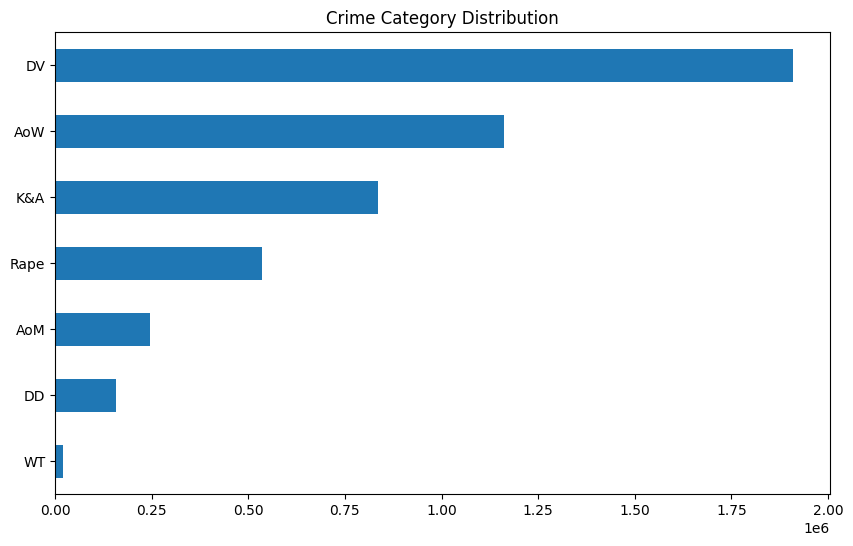

In [94]:
df[crime_cols].sum().sort_values().plot(
    kind = "barh",
    figsize = (10,6)
)

plt.title("Crime Category Distribution")
plt.show()


In [95]:
# hence we can see domestic violence is the highest

Q3 Year Wise Crime Trend

In [63]:
yearly = df.groupby('Year')['Total_Crimes'].sum()
yearly.head()

,Total_Crimes
Year,
2001,128537
2002,128972
2003,128142
2004,140072
2005,139333


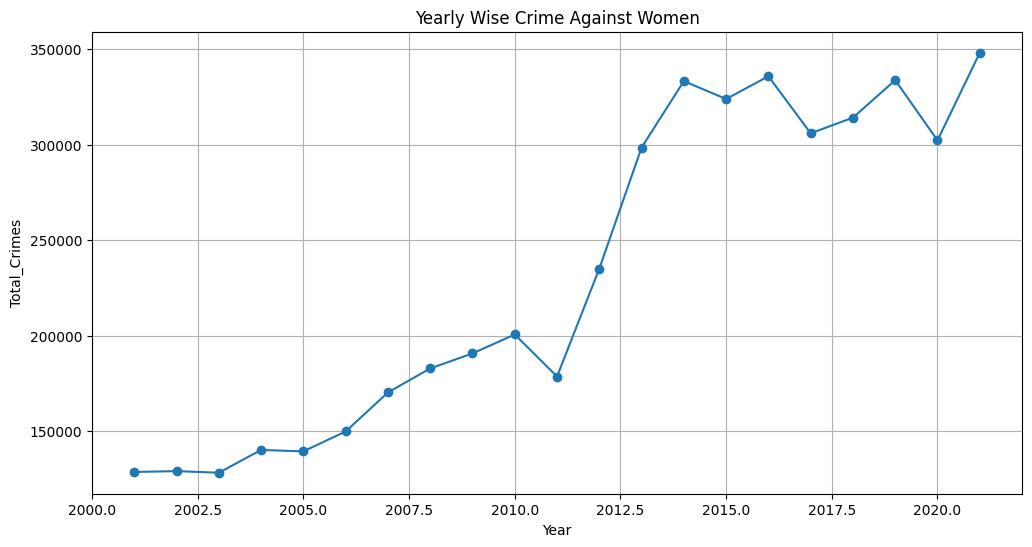

In [64]:
plt.figure(figsize=(12,6))
yearly.plot(marker = 'o')
plt.title("Yearly Wise Crime Against Women")
plt.xlabel("Year")
plt.ylabel("Total_Crimes")

plt.grid()
plt.show()

Q4 State with Highest Rape Cases

In [65]:
df.groupby('State')['Rape'].sum().sort_values(
    ascending= False
).head(10)

,Rape
State,
Madhya Pradesh,43552
Rajasthan,31850
Uttar Pradesh,30641
MADHYA PRADESH,29256
Maharashtra,24806
Assam,19428
Kerala,18888
Punjab,18762
WEST BENGAL,16378


Madhya Pardesh have highest Rape Case

## Q5 State with Highest Domestic Violence **Cases**

In [66]:
df.groupby('State')['DV'].sum().sort_values(
    ascending = False
).head(10)

,DV
State,
West Bengal,171204
Rajasthan,126917
Assam,107680
Uttar Pradesh,100227
Andhra Pradesh,96269
ANDHRA PRADESH,92242
WEST BENGAL,91031
RAJASTHAN,74571
Maharashtra,67545


Q6 Correlation between Crimes

In [67]:
corr = df[crime_cols].corr()

corr

,Rape,K&A,DD,AoW,AoM,DV,WT
Rape,1.000000,0.700730,0.553497,0.804336,0.458025,0.680321,0.219218
K&A,0.700730,1.000000,0.691524,0.671159,0.355703,0.685999,0.179016
DD,0.553497,0.691524,1.000000,0.456012,0.422970,0.487465,0.093254
AoW,0.804336,0.671159,0.456012,1.000000,0.521432,0.631558,0.284338
AoM,0.458025,0.355703,0.422970,0.521432,1.000000,0.419300,0.260077
DV,0.680321,0.685999,0.487465,0.631558,0.419300,1.000000,0.280839
WT,0.219218,0.179016,0.093254,0.284338,0.260077,0.280839,1.000000


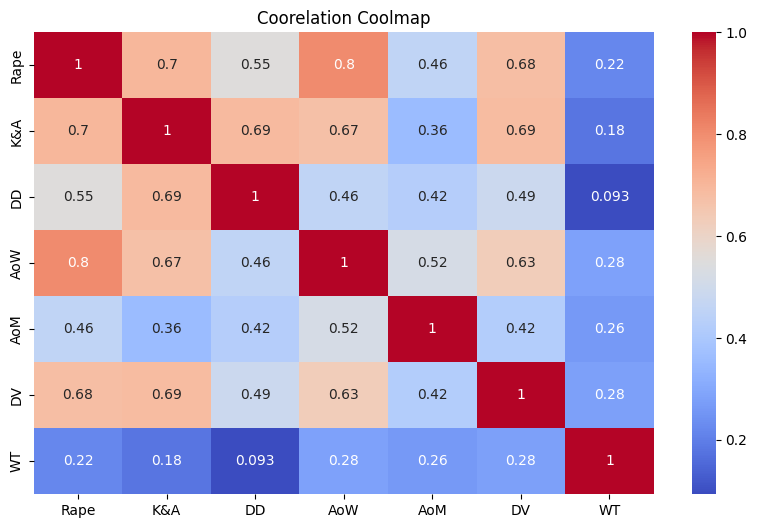

In [68]:
plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    annot = True,
    cmap = 'coolwarm'
)


plt.title("Coorelation Coolmap")
plt.show()

In [77]:
df['State'] = df['State'].str.title().str.strip()

In [78]:
df['State'].nunique()
df['State'].unique()

array(['Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar',
       'Chhattisgarh', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh',
       'Jammu & Kashmir', 'Jharkhand', 'Karnataka', 'Kerala',
       'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram',
       'Nagaland', 'Odisha', 'Punjab', 'Rajasthan', 'Sikkim',
       'Tamil Nadu', 'Tripura', 'Uttar Pradesh', 'Uttarakhand',
       'West Bengal', 'A & N Islands', 'Chandigarh', 'D & N Haveli',
       'Daman & Diu', 'Lakshadweep', 'Puducherry', 'Telangana',
       'D&N Haveli', 'Delhi Ut'], dtype=object)

In [79]:
df.groupby('Year')['Total_Crimes'].sum()

,Total_Crimes
Year,
2001,128537
2002,128972
2003,128142
2004,140072
2005,139333
2006,149742
2007,170196
2008,182757
2009,190617


Q7) State wise Heatmap

In [80]:
pivot = df.pivot_table(
    values='Total_Crimes',
    index='State',
    columns='Year',
    aggfunc='sum'
)

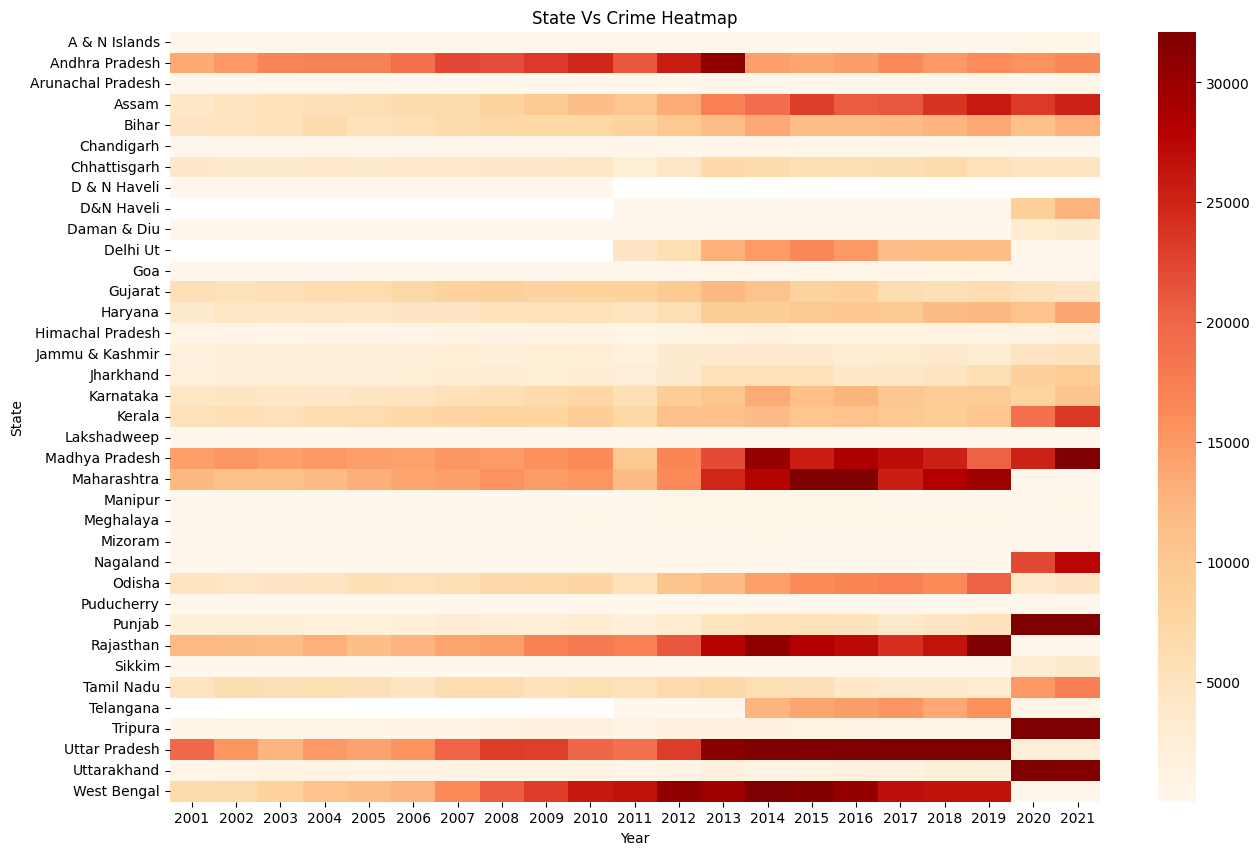

In [82]:
plt.figure(figsize=(15,10))
sns.heatmap(
   pivot,
   cmap = 'OrRd',
   robust = True
)

plt.title("State Vs Crime Heatmap")
plt.show()

In [87]:
df[df['State'] == 'Maharashtra'][['Year', 'Total_Crimes']]

,Year,Total_Crimes
14,2001,12255
48,2002,11113
82,2003,11057
116,2004,11828
150,2005,13117
184,2006,14010
218,2007,14555
252,2008,15485
286,2009,14726
320,2010,15391


A Key Insight

In [89]:
df['State'].nunique()

37

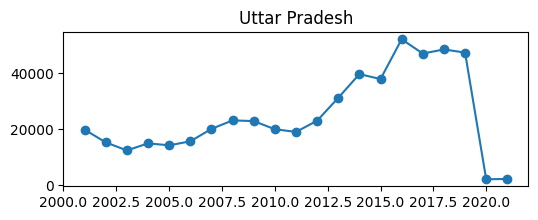

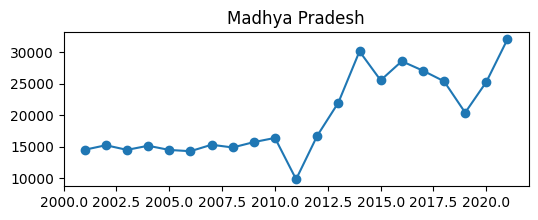

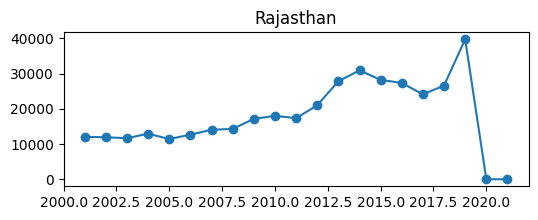

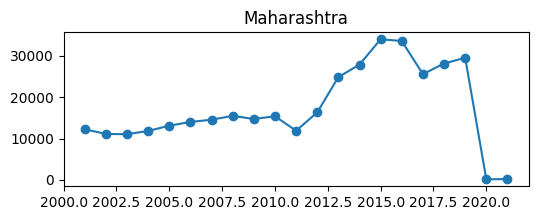

In [91]:
top_states = ['Uttar Pradesh', 'Madhya Pradesh', 'Rajasthan', 'Maharashtra']

for state in top_states:
    temp = df[df['State'] == state]
    plt.figure(figsize=(6,2))
    plt.plot(temp['Year'], temp['Total_Crimes'], marker='o')
    plt.title(state)
    plt.show()